# Spam-/Phishing-Erkennung für die Mercedes-Benz AG
### Fallstudie Machine Learning – Artificial Intelligence (M.Sc.), Hochschule Reutlingen

**Geschäftsproblem.** Die Mercedes-Benz AG (weltweit führender Premium-Automobilhersteller,
Teil eines Konzerns mit über 160.000 Mitarbeitenden) verarbeitet täglich enorme Mengen an E-Mails. Spam- und Phishing-Nachrichten
kosten Arbeitszeit, belasten die IT und sind ein **Sicherheitsrisiko** (Phishing ist ein
Haupteinfallstor für Angriffe). Ein Machine-Learning-Modell soll eingehende E-Mails
automatisch in **Spam** und **legitim** klassifizieren.

**Lernaufgabe.** Binäre Klassifikation: Zielvariable `spam` (1 = Spam, 0 = legitim).

**Vorgehen (CRISP-DM).** Business Understanding → Data Understanding → Data Preparation →
Modeling → Evaluation → Deployment.

> **Datensatz:** öffentlicher *Spambase*-Datensatz (UCI Machine Learning Repository,
> Hopkins et al. 1999), 4.601 reale E-Mails mit 57 numerischen Merkmalen (Wort- und
> Zeichenhäufigkeiten, Großbuchstaben-Läufe). Er stammt aus einem realen Firmen-Mailsystem
> und dient als realitätsnahe Grundlage. Die Fallstudie bildet bewusst keine realen internen
> E-Mail-Daten der Mercedes-Benz AG ab, sondern einen übertragbaren Anwendungsfall.

## 1. Bibliotheken importieren

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             roc_curve, precision_recall_curve, classification_report)
RANDOM_STATE = 42
plt.rcParams.update({"figure.dpi": 110, "font.size": 11})

## 2. Daten laden und inspizieren
Jede Zeile ist eine E-Mail, jede Spalte ein Merkmal. Die meisten Merkmale geben an, wie
häufig ein bestimmtes Wort oder Zeichen in der Mail vorkommt (in %). Die Zielvariable
`spam` ist 1 (Spam) oder 0 (legitim).

In [2]:
df = pd.read_csv("spambase.csv").rename(columns={"type": "spam"})
print("Form:", df.shape)
print("Spam-Quote: {:.1%}".format(df["spam"].mean()))
print("Fehlende Werte:", int(df.isna().sum().sum()))
df.head()

Form: (4601, 58)
Spam-Quote: 39.4%
Fehlende Werte: 0


,make,address,all,num3d,our,over,remove,internet,order,mail,...,charSemicolon,charRoundbracket,charSquarebracket,charExclamation,charDollar,charHash,capitalAve,capitalLong,capitalTotal,spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


Der Datensatz enthält **4.601 E-Mails** mit **57 Merkmalen**, **keine fehlenden Werte**,
und ist mit ~39 % Spam **nur leicht unbalanciert**. Alle Merkmale sind bereits numerisch –
ein separates Encoding kategorialer Variablen ist daher nicht nötig.

## 3. Explorative Datenanalyse (EDA)

### 3.1 Verteilung der Zielvariable

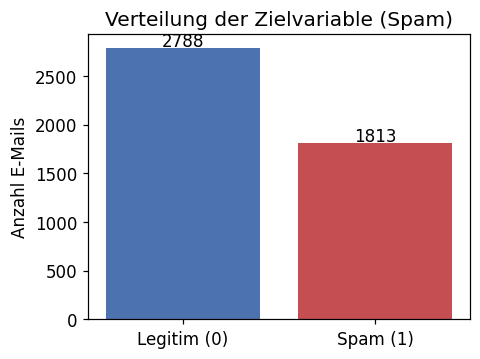

In [3]:
fig, ax = plt.subplots(figsize=(4.5,3.4))
vc = df["spam"].value_counts().sort_index()
ax.bar(["Legitim (0)","Spam (1)"], vc.values, color=["#4C72B0","#C44E52"])
for i,v in enumerate(vc.values): ax.text(i, v+20, str(v), ha="center")
ax.set_title("Verteilung der Zielvariable (Spam)"); ax.set_ylabel("Anzahl E-Mails")
plt.tight_layout(); plt.show()

### 3.2 Welche Wörter deuten auf Spam hin?
Wir vergleichen die mittlere Worthäufigkeit in Spam- und legitimen Mails.

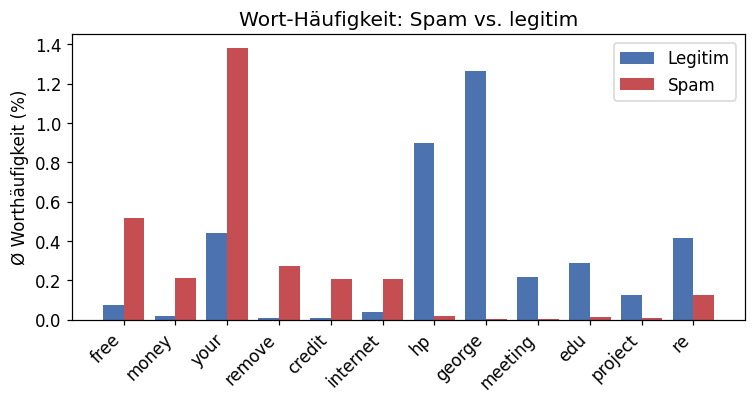

In [4]:
tokens = ["free","money","your","remove","credit","internet","hp","george","meeting","edu","project","re"]
spam_mean = df[df.spam==1][tokens].mean(); ham_mean = df[df.spam==0][tokens].mean()
x = np.arange(len(tokens)); w = 0.4
fig, ax = plt.subplots(figsize=(7,3.8))
ax.bar(x-w/2, ham_mean.values, w, label="Legitim", color="#4C72B0")
ax.bar(x+w/2, spam_mean.values, w, label="Spam", color="#C44E52")
ax.set_xticks(x); ax.set_xticklabels(tokens, rotation=45, ha="right")
ax.set_ylabel("Ø Worthäufigkeit (%)"); ax.set_title("Wort-Häufigkeit: Spam vs. legitim"); ax.legend()
plt.tight_layout(); plt.show()

**Befund:** Wörter wie *free, money, your, remove, credit* treten in Spam viel häufiger
auf; *hp, george, meeting, edu, project* dagegen in legitimen (geschäftlichen) Mails. Das
deckt sich mit der Intuition über Werbe-/Phishing-Sprache.

### 3.3 Großbuchstaben-Nutzung
Spam nutzt oft viele Großbuchstaben (z. B. GRATIS!!!).

/sessions/pensive-peaceful-ptolemy/tmp/ipykernel_9/605483361.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([np.log1p(df[df.spam==0]["capitalTotal"]), np.log1p(df[df.spam==1]["capitalTotal"])],


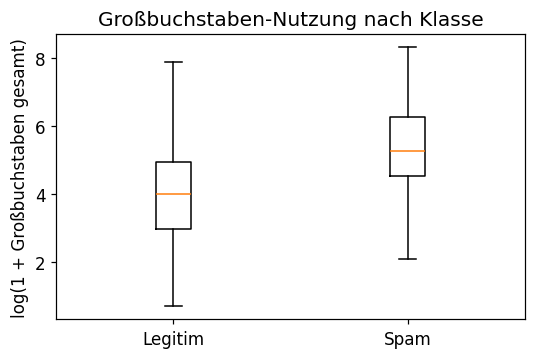

In [5]:
fig, ax = plt.subplots(figsize=(5,3.4))
ax.boxplot([np.log1p(df[df.spam==0]["capitalTotal"]), np.log1p(df[df.spam==1]["capitalTotal"])],
           labels=["Legitim","Spam"], showfliers=False)
ax.set_ylabel("log(1 + Großbuchstaben gesamt)"); ax.set_title("Großbuchstaben-Nutzung nach Klasse")
plt.tight_layout(); plt.show()

### 3.4 Stärkste Korrelationen mit der Zielvariable

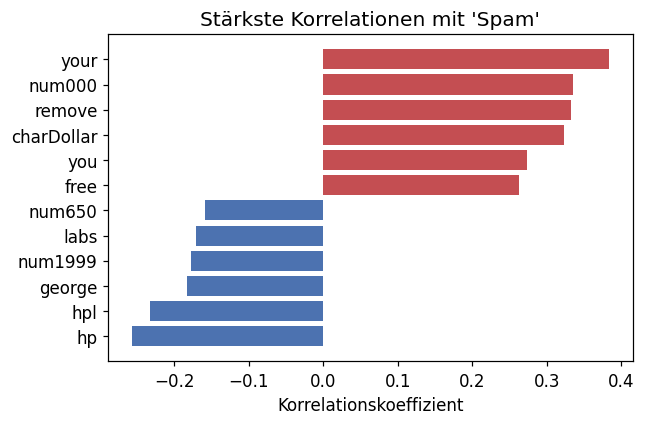

In [6]:
corr = df.corr(numeric_only=True)["spam"].drop("spam").sort_values()
top_corr = pd.concat([corr.head(6), corr.tail(6)])
colors = ["#4C72B0" if v<0 else "#C44E52" for v in top_corr.values]
fig, ax = plt.subplots(figsize=(6,4))
ax.barh(top_corr.index, top_corr.values, color=colors)
ax.set_title("Stärkste Korrelationen mit 'Spam'"); ax.set_xlabel("Korrelationskoeffizient")
plt.tight_layout(); plt.show()

## 4. Datenvorbereitung
- Trennung von Zielvariable (`spam`) und den 57 Eingangsmerkmalen.
- **Stratifizierter** 80/20-Split → gleiche Spam-Quote in Training und Test.
- **Standardisierung** (wichtig für logistische Regression und neuronales Netz);
  Scaler wird **nur auf den Trainingsdaten** gefittet → vermeidet Data Leakage.

In [7]:
y = df["spam"]; X = df.drop(columns=["spam"])
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)
print("Train:", X_train.shape[0], "| Test:", X_test.shape[0])
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train); X_test_s = scaler.transform(X_test)

Train: 3680 | Test: 921


## 5. Modellbildung
Drei Verfahren im Vergleich: **Logistische Regression** (interpretierbares Basismodell),
**Random Forest** (Ensemble, nichtlinear) und **neuronales Netz (MLP)**. Bei den ersten
beiden gleicht `class_weight="balanced"` die leichte Klassenungleichheit aus.

In [8]:
models = {
    "Logistische Regression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
    "Neuronales Netz (MLP)": MLPClassifier(hidden_layer_sizes=(64,32), max_iter=600, early_stopping=True, random_state=RANDOM_STATE),
}
metrics, roc_data, proba_store = {}, {}, {}
for name, model in models.items():
    model.fit(X_train_s, y_train)
    proba = model.predict_proba(X_test_s)[:,1]; proba_store[name]=proba
    pred = (proba>=0.5).astype(int)
    metrics[name] = {"Accuracy":accuracy_score(y_test,pred),"Precision":precision_score(y_test,pred),
                     "Recall":recall_score(y_test,pred),"F1":f1_score(y_test,pred),
                     "ROC_AUC":roc_auc_score(y_test,proba)}
    fpr,tpr,_ = roc_curve(y_test,proba); roc_data[name]=(fpr,tpr,metrics[name]["ROC_AUC"])
pd.DataFrame(metrics).T.round(4)

,Accuracy,Precision,Recall,F1,ROC_AUC
Logistische Regression,0.9218,0.8901,0.9146,0.9022,0.9704
Random Forest,0.9468,0.9486,0.9146,0.9313,0.9832
Neuronales Netz (MLP),0.9316,0.9144,0.9118,0.9131,0.9760


## 6. Evaluation
Beim Spam-Filter zählen **beide** Fehlertypen: durchgelassene Spam (False Negative) ist ein
Sicherheits-/Zeitrisiko, eine fälschlich blockierte legitime Mail (False Positive) ist
ärgerlich und potenziell geschäftsschädigend. Deshalb betrachten wir Precision, Recall, F1
und die schwellenunabhängige ROC-AUC.

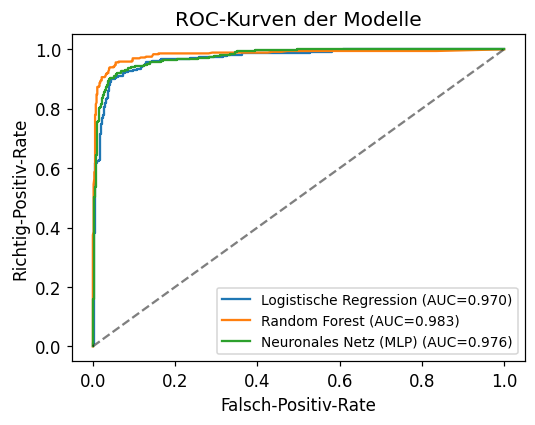

In [9]:
fig, ax = plt.subplots(figsize=(5,4))
for name,(fpr,tpr,auc) in roc_data.items(): ax.plot(fpr,tpr,label=f"{name} (AUC={auc:.3f})")
ax.plot([0,1],[0,1],"k--",alpha=0.5)
ax.set_xlabel("Falsch-Positiv-Rate"); ax.set_ylabel("Richtig-Positiv-Rate")
ax.set_title("ROC-Kurven der Modelle"); ax.legend(loc="lower right", fontsize=9)
plt.tight_layout(); plt.show()

Bestes Modell (ROC-AUC): Random Forest
              precision    recall  f1-score   support

     Legitim       0.94      0.97      0.96       558
        Spam       0.95      0.91      0.93       363

    accuracy                           0.95       921
   macro avg       0.95      0.94      0.94       921
weighted avg       0.95      0.95      0.95       921



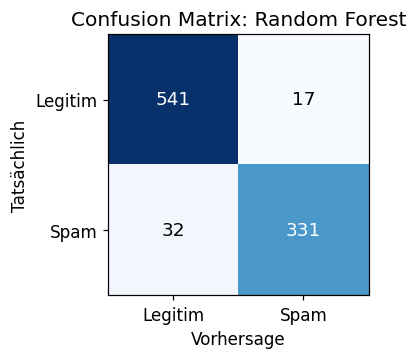

In [10]:
best_name = max(metrics, key=lambda k: metrics[k]["ROC_AUC"])
print("Bestes Modell (ROC-AUC):", best_name)
best = models[best_name]; pred_best = best.predict(X_test_s)
print(classification_report(y_test, pred_best, target_names=["Legitim","Spam"]))
cm = confusion_matrix(y_test, pred_best)
fig, ax = plt.subplots(figsize=(4,3.4)); ax.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax.text(j,i,cm[i,j],ha="center",va="center",color="white" if cm[i,j]>cm.max()/2 else "black",fontsize=12)
ax.set_xticks([0,1]); ax.set_xticklabels(["Legitim","Spam"]); ax.set_yticks([0,1]); ax.set_yticklabels(["Legitim","Spam"])
ax.set_xlabel("Vorhersage"); ax.set_ylabel("Tatsächlich"); ax.set_title(f"Confusion Matrix: {best_name}")
plt.tight_layout(); plt.show()

Der **Random Forest** erzielt die beste Gesamtleistung (höchste ROC-AUC und F1) und fängt
über 91 % der Spam-Mails bei nur rund 3 % Fehlalarmen – ein sehr guter Kompromiss für den
Anwendungsfall. Er wird als bevorzugtes Modell gewählt.

## 7. Interpretation: Welche Merkmale sind entscheidend?

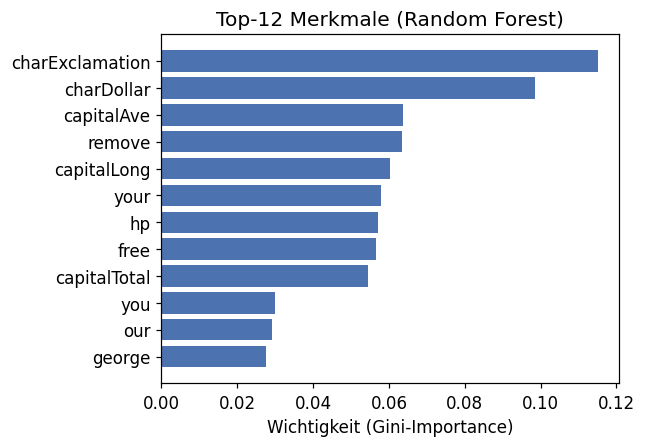

charExclamation    0.115028
charDollar         0.098443
capitalAve         0.063636
remove             0.063479
capitalLong        0.060357
your               0.057881
hp                 0.056997
free               0.056468
capitalTotal       0.054384
you                0.029935
dtype: float64

In [11]:
rf = models["Random Forest"]
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
top = imp.head(12)[::-1]
fig, ax = plt.subplots(figsize=(6,4.2)); ax.barh(top.index, top.values, color="#4C72B0")
ax.set_title("Top-12 Merkmale (Random Forest)"); ax.set_xlabel("Wichtigkeit (Gini-Importance)")
plt.tight_layout(); plt.show(); imp.head(10)

In [12]:
lr = models["Logistische Regression"]
coefs = pd.Series(lr.coef_[0], index=X.columns).sort_values()
print("Senken Spam-Wahrscheinlichkeit (→ legitim):\n", coefs.head(6).round(3))
print("\nErhöhen Spam-Wahrscheinlichkeit:\n", coefs.tail(6).round(3))

Senken Spam-Wahrscheinlichkeit (→ legitim):
 george    -4.250
hp        -2.324
cs        -1.686
num85     -1.431
edu       -1.428
meeting   -1.417
dtype: float64

Erhöhen Spam-Wahrscheinlichkeit:
 num000         0.882
remove         0.904
charHash       0.934
capitalAve     1.310
charDollar     1.457
capitalLong    1.522
dtype: float64


**Interpretation:** Ausrufezeichen (`!`), Dollarzeichen (`$`), viele Großbuchstaben sowie
Wörter wie *remove, free, your, 000* sind starke Spam-Indikatoren. Umgekehrt deuten
firmen-/personenbezogene Begriffe (*hp, george, meeting, edu, cs*) klar auf legitime Mails –
das spiegelt den betrieblichen Ursprung der Daten wider.

## 8. Threshold-Optimierung
Die Schwelle 0,5 ist nicht zwingend optimal. Über die Schwelle steuert man den Kompromiss
zwischen „möglichst viel Spam fangen" (hoher Recall) und „möglichst keine legitimen Mails
blockieren" (hohe Precision).

F1-optimale Schwelle: 0.443


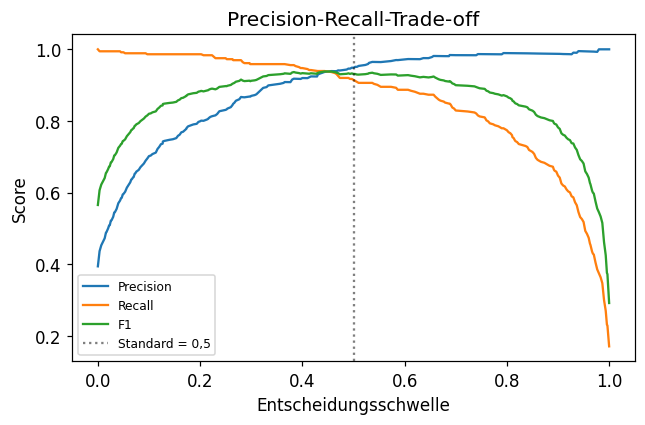

In [13]:
proba_best = best.predict_proba(X_test_s)[:,1]
prec, rec, thr = precision_recall_curve(y_test, proba_best)
f1s = 2*prec*rec/(prec+rec+1e-9); bi = int(np.argmax(f1s[:-1]))
print(f"F1-optimale Schwelle: {thr[bi]:.3f}")
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(thr, prec[:-1], label="Precision"); ax.plot(thr, rec[:-1], label="Recall"); ax.plot(thr, f1s[:-1], label="F1")
ax.axvline(0.5, color="black", ls=":", alpha=0.5, label="Standard = 0,5")
ax.set_xlabel("Entscheidungsschwelle"); ax.set_ylabel("Score"); ax.set_title("Precision-Recall-Trade-off"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

Für einen Spam-Filter würde man die Schwelle eher **vorsichtig** wählen (legitime Mails
nicht zu blockieren) und besonders kritische Treffer in einen **Quarantäne-Ordner** statt in
den Papierkorb verschieben.

## 9. Deployment, Services & Fazit
**Deployment:** Das Modell läuft als Dienst direkt am **Mail-Gateway**: jede eingehende Mail
wird in Echtzeit bewertet; hohe Spam-Wahrscheinlichkeit → Quarantäne, niedrige → Posteingang.
Wichtig ist **Monitoring auf Datendrift**, da sich Spam-Muster ständig ändern (regelmäßiges
Re-Training).

**Datenbasierte Services:** automatischer Spam-Filter, Phishing-Frühwarnung für das
Security-Team, Quarantäne-Self-Service, Security-Dashboard.

**Effekte:** weniger Phishing-Risiko, gesparte Arbeitszeit, entlastete IT.

**Fazit:** Spam lässt sich mit Standard-ML sehr zuverlässig erkennen (ROC-AUC ≈ 0,98). Die
wichtigsten Signale sind Sonderzeichen, Großschreibung und typische Werbewörter. Der Random
Forest bietet die beste Balance aus Erkennungsrate und niedriger Fehlalarmquote.

**Nächste Schritte:** Hyperparameter-Tuning, kostenbasierte Schwelle, Erklärbarkeit (SHAP),
Drift-Monitoring im Betrieb.